#📌 Extracción

In [21]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [20]:
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

# Convertir JSON a DataFrame
df = pd.json_normalize(data)

# Mostrar primeras filas
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


Exploración inicial

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.columns

#🔧 Transformación

In [22]:
df.columns = df.columns.str.replace('.', '_', regex=False)

df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

In [23]:
df["account_Charges_Total"] = pd.to_numeric(
    df["account_Charges_Total"],
    errors="coerce"
)

Verificacion de valores nulos

In [ ]:
df.isnull().sum()

Elimino registros incompletos.

In [ ]:
df = df.dropna()

Nueva variable auxiliar

In [ ]:
df["Charges_Daily"] = df["account_Charges_Monthly"] / 30

Validación final

In [ ]:
df.info()

In [ ]:
df.describe()

#📊 Carga y análisis

In [24]:
df.to_csv("TelecomX_clean.csv", index=False)

Análisis rápido

In [25]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


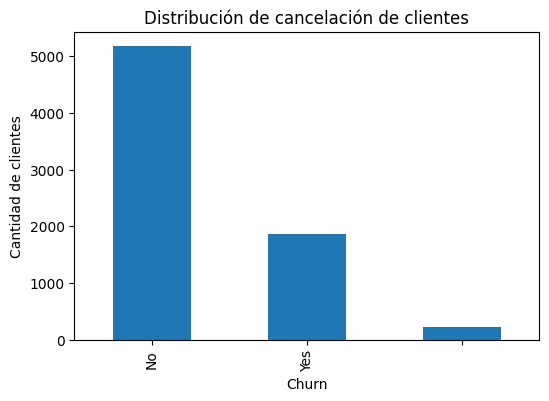

In [26]:
plt.figure(figsize=(6,4))

df["Churn"].value_counts().plot(kind="bar")

plt.title("Distribución de cancelación de clientes")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")

plt.show()

#📄Informe final

**En este proyecto se implementó un proceso completo de ETL (Extract, Transform, Load) utilizando Python.

Los datos fueron extraídos desde una API en formato JSON. Debido a que la información presentaba una estructura jerárquica, fue necesario aplicar procesos de normalización para convertir los datos en un formato tabular.

Posteriormente se realizaron tareas de limpieza y transformación, incluyendo la conversión de tipos de datos, tratamiento de valores nulos y creación de variables derivadas. Finalmente, el dataset limpio fue almacenado para su posterior análisis.

Este proceso demuestra la importancia de la preparación de datos dentro del flujo de trabajo de análisis, permitiendo obtener datasets estructurados y confiables para generar insights.**